In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error as rmse
import graphviz
import re
import dtreeviz

In [2]:
df = pd.read_csv('../data/TrainAndValid.csv', parse_dates=['saledate'], low_memory=False)
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   object        
 9   saledate                  412698 non-null  datetime64[ns]
 10  fiModelDesc               412698 non-null  object        
 11  fiBaseModel               412698 non-null  object        
 12  fi

In [4]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

what is the missing percent in each column

In [5]:
miss_pct = df.isna().mean()
miss_pct

SalesID                     0.000000
SalePrice                   0.000000
MachineID                   0.000000
ModelID                     0.000000
datasource                  0.000000
auctioneerID                0.048791
YearMade                    0.000000
MachineHoursCurrentMeter    0.642586
UsageBand                   0.821492
saledate                    0.000000
fiModelDesc                 0.000000
fiBaseModel                 0.000000
fiSecondaryDesc             0.340993
fiModelSeries               0.857845
fiModelDescriptor           0.818715
ProductSize                 0.524851
fiProductClassDesc          0.000000
state                       0.000000
ProductGroup                0.000000
ProductGroupDesc            0.000000
Drive_System                0.740520
Enclosure                   0.000809
Forks                       0.520921
Pad_Type                    0.803498
Ride_Control                0.629928
Stick                       0.803498
Transmission                0.544444
T

What are the columns with more than 90%

In [6]:
miss_pct[miss_pct > 0.9]

Blade_Extension      0.937041
Blade_Width          0.937041
Enclosure_Type       0.937041
Engine_Horsepower    0.937041
Pushblock            0.937041
Scarifier            0.937014
Tip_Control          0.937041
dtype: float64

In [7]:
cols_to_drop = miss_pct[miss_pct > 0.9].index.tolist()
df.drop(cols_to_drop, axis=1, inplace=True)

First we need to handle ordinal columns, Those are columns containing strings but they have a natural order for example like small, medium, and large

In [8]:
df['ProductSize'].unique()

array([nan, 'Medium', 'Small', 'Large / Medium', 'Mini', 'Large',
       'Compact'], dtype=object)

In [9]:
df['UsageBand'].unique()

array(['Low', 'High', 'Medium', nan], dtype=object)

In [10]:
df['Hydraulics_Flow'].unique()

array([nan, 'Standard', 'High Flow', 'None or Unspecified'], dtype=object)

In [11]:
df['Grouser_Type'].unique()

array([nan, 'Double', 'Triple', 'Single'], dtype=object)

Surprisingly, this column doesn't contain actual horsepower ratings, just leave this column as it is

In [12]:
df['Undercarriage_Pad_Width'].unique()

array([nan, 'None or Unspecified', '16 inch', '32 inch', '28 inch',
       '30 inch', '22 inch', '24 inch', '18 inch', '36 inch', '20 inch',
       '27 inch', '15 inch', '26 inch', '34 inch', '33 inch', '14 inch',
       '31 inch', '25 inch', '31.5 inch'], dtype=object)

`Undercarriage_Pad_Width` contains numeric measurements that can be extracted and ordered

same with `Blade_Width` but we need to handle "<12" special case

In [13]:
df['Stick_Length'].unique()

array([nan, 'None or Unspecified', '11\' 0"', '15\' 9"', '10\' 2"',
       '10\' 6"', '9\' 10"', '10\' 10"', '9\' 6"', '9\' 7"', '12\' 8"',
       '8\' 2"', '8\' 6"', '9\' 8"', '12\' 10"', '11\' 10"', '8\' 10"',
       '8\' 4"', '12\' 4"', '9\' 5"', '6\' 3"', '14\' 1"', '13\' 7"',
       '13\' 10"', '13\' 9"', '7\' 10"', '15\' 4"', '9\' 2"', '24\' 3"',
       '19\' 8"'], dtype=object)

`Stick_Length` contains measurements in feet and inches

In [14]:
df['Tire_Size'].unique()

array(['None or Unspecified', '23.5', nan, '13"', '26.5', '29.5', '14"',
       '20.5', '17.5"', '15.5"', '20.5"', '17.5', '7.0"', '15.5', '23.5"',
       '10"', '23.1"', '10 inch'], dtype=object)

`Tire_size` columns is quite messy, this is probably because this dataset is merged from multiply sources

In [15]:
df['Undercarriage_Pad_Width'].value_counts(dropna=False)

Undercarriage_Pad_Width
NaN                    309782
None or Unspecified     82444
32 inch                  5287
28 inch                  3152
24 inch                  2998
20 inch                  2664
30 inch                  1602
36 inch                  1544
18 inch                  1439
34 inch                   540
16 inch                   481
31 inch                   191
27 inch                   144
22 inch                   135
26 inch                    98
33 inch                    94
14 inch                    51
15 inch                    33
25 inch                    17
31.5 inch                   2
Name: count, dtype: int64

so `nan` and 'None or Unspecified' is actually different, `nan` indicate the data is truly missing, nothing was recorded, while 'None or Unspecified' indicate someone explicitly recorded that the machine ether doesn't have this feature or its specification wasn't provided

In [16]:
df['Stick_Length'].value_counts(dropna=False)

Stick_Length
NaN                    310437
None or Unspecified     81539
9' 6"                    5832
10' 6"                   3519
11' 0"                   1601
9' 10"                   1463
9' 8"                    1462
9' 7"                    1423
12' 10"                  1087
10' 2"                   1004
8' 6"                     908
8' 2"                     614
10' 10"                   414
12' 8"                    322
11' 10"                   307
8' 4"                     274
8' 10"                    104
12' 4"                    103
9' 5"                     101
15' 9"                     87
6' 3"                      51
13' 7"                     11
14' 1"                      7
13' 10"                     7
13' 9"                      7
19' 8"                      5
7' 10"                      3
15' 4"                      3
24' 3"                      2
9' 2"                       1
Name: count, dtype: int64

In [17]:
df['Tire_Size'].value_counts(dropna=False)

Tire_Size
NaN                    315060
None or Unspecified     47823
20.5                    15773
14"                      9111
23.5                     8760
26.5                     4635
17.5                     3971
29.5                     2767
17.5"                    1815
13"                       776
20.5"                     737
15.5                      610
15.5"                     463
23.5"                     309
7.0"                       56
23.1"                      20
10"                         9
10 inch                     3
Name: count, dtype: int64

In [18]:
size_order = ['Mini', 'Compact', 'Small', 'Medium', 'Large / Medium', 'Large']
df['ProductSize'] = pd.Categorical(df['ProductSize'], categories=size_order, ordered=True)
df['ProductSize'].head(5)

0       NaN
1    Medium
2       NaN
3     Small
4       NaN
Name: ProductSize, dtype: category
Categories (6, object): ['Mini' < 'Compact' < 'Small' < 'Medium' < 'Large / Medium' < 'Large']

In [19]:
usage_order = ['Low', 'Medium', 'High']
df['UsageBand'] = pd.Categorical(df['UsageBand'], categories=usage_order, ordered=True)

In [20]:
flow_order = ['None or Unspecified', 'Standard', 'High Flow']
df['Hydraulics_Flow'] = pd.Categorical(df['Hydraulics_Flow'], categories=flow_order, ordered=True)
df['Hydraulics_Flow'].head(5)

0         NaN
1         NaN
2    Standard
3         NaN
4    Standard
Name: Hydraulics_Flow, dtype: category
Categories (3, object): ['None or Unspecified' < 'Standard' < 'High Flow']

In [21]:
grouser_order = ['Double', 'Triple', 'Single']
df['Grouser_Type'] = pd.Categorical(df['Grouser_Type'], categories=grouser_order, ordered=True)
df['Grouser_Type'].head(5)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Grouser_Type, dtype: category
Categories (3, object): ['Double' < 'Triple' < 'Single']

so to distinct nan and None or unspecified i will fill nan with -2 and None or unspecified with -1

In [22]:
def extract_pad_width(x):
    if pd.isna(x): return -2
    if x == 'None or Unspecified': return -1
    return float(x.split(' ')[0])

In [23]:
df['Undercarriage_Pad_Width_num'] = df['Undercarriage_Pad_Width'].apply(extract_pad_width)
df['Undercarriage_Pad_Width_num'].head()

0   -2.0
1   -2.0
2   -2.0
3   -2.0
4   -2.0
Name: Undercarriage_Pad_Width_num, dtype: float64

In [24]:
def extract_stick_length(x):
    if pd.isna(x): return -2
    if x == 'None or Unspecified': return -1
    parts = x.replace('"', '').split("' ")
    feet = float(parts[0])
    inches = float(parts[1]) if len(parts) > 1 else 0
    return feet * 12 + inches # convert to total inches

In [25]:
df['Stick_Length_inches'] = df['Stick_Length'].apply(extract_stick_length)
df['Stick_Length_inches'].head()

0   -2.0
1   -2.0
2   -2.0
3   -2.0
4   -2.0
Name: Stick_Length_inches, dtype: float64

In [26]:
def extract_tire_size(x):
    if pd.isna(x): return -2
    if x == 'None or Unspecified': return -1
    if 'inch' in x: return float(x.split(' ')[0])
    return float(x.replace('"', ''))

In [27]:
df['Tire_Size_num'] = df['Tire_Size'].apply(extract_tire_size)
df['Tire_Size_num'].head()

0    -1.0
1    23.5
2    -2.0
3    -2.0
4    -2.0
Name: Tire_Size_num, dtype: float64

In [28]:
original_cols_to_drop = ['Stick_Length', 'Undercarriage_Pad_Width', 'Tire_Size']
df.drop(original_cols_to_drop, axis=1, inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 46 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   SalesID                      412698 non-null  int64         
 1   SalePrice                    412698 non-null  float64       
 2   MachineID                    412698 non-null  int64         
 3   ModelID                      412698 non-null  int64         
 4   datasource                   412698 non-null  int64         
 5   auctioneerID                 392562 non-null  float64       
 6   YearMade                     412698 non-null  int64         
 7   MachineHoursCurrentMeter     147504 non-null  float64       
 8   UsageBand                    73670 non-null   category      
 9   saledate                     412698 non-null  datetime64[ns]
 10  fiModelDesc                  412698 non-null  object        
 11  fiBaseModel               

This pattern strong suggests that Coupler_system is only relevant for SSL and not applicable to other machine type, so what do we do with this?

In [30]:
idx = df['YearMade'] > df['saledate'].dt.year
df[idx]

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,Undercarriage_Pad_Width_num,Stick_Length_inches,Tire_Size_num
27786,1256766,27000.0,1424836,3247,132,2.0,1997,NaN,NaN,1996-12-13,...,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN,-1.0,-1.0,-2.0
81843,1380049,29000.0,1189094,3538,132,1.0,2000,NaN,NaN,1999-10-14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,-2.0,-2.0
161311,1582210,60000.0,1482307,28842,132,1.0,2006,NaN,NaN,2005-02-15,...,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN,-1.0,-1.0,-2.0
176543,1607397,72000.0,1104056,4753,132,11.0,1998,NaN,NaN,1997-05-29,...,NaN,NaN,NaN,NaN,NaN,Standard,Conventional,-2.0,-2.0,-1.0
206920,1656135,26500.0,1229496,8559,132,1.0,1998,NaN,NaN,1996-02-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,-2.0,-1.0
209191,1662009,8500.0,1481256,14755,132,2.0,2008,NaN,NaN,2001-10-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,-2.0,-2.0
213253,1672382,12000.0,1151751,4988,132,4.0,2008,NaN,NaN,1996-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,-2.0,-2.0
231762,1725834,22500.0,1106818,8954,132,1.0,2006,NaN,NaN,1996-07-16,...,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN,-1.0,-1.0,-2.0
242681,1748962,27000.0,1361981,257,132,6.0,2008,NaN,NaN,1997-12-15,...,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN,-2.0,-2.0,-2.0
251546,1766755,100000.0,1241578,457,132,6.0,2002,NaN,NaN,1995-08-11,...,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN,-1.0,126.0,-2.0


As discuss in EDA notebook we will fill it with the same date as the `saledate` year

In [31]:
df.loc[idx, 'YearMade'] = df.loc[idx, 'saledate'].dt.year

In [32]:
df['YearMade'].unique().min()

np.int64(1000)

also `YearMade` = 1000 is a placeholder for missing values as discussed in EDA notebook so we will assign it with 1950

In [33]:
df.loc[df['YearMade'] < 1900, 'YearMade'] = 1950

### handling date

as we wil use tree based model it just basically divides the group into two, so when it comes to date data type, we should treat it the same as ordinal datatype, since dates also have natural order(one date is greater than other). However date are a bit different because some date may be associated with special events that can significantly effect the sale price, such as wether that day has a sale-off, is a holiday, or coincides with major events or promotions, so we would like our model to know more than just whether a date is more or less recent than another

In [34]:
df['saleYear'] = df['saledate'].dt.year
df['saleMonth'] = df['saledate'].dt.month
df['saleDay'] = df['saledate'].dt.day
df['saleWeek'] = df['saledate'].dt.isocalendar().week
df['saleDayofweek'] = df['saledate'].dt.dayofweek
df['saleDayofyear'] = df['saledate'].dt.dayofyear

In [35]:
df['saleIs_month_end'] = df['saledate'].dt.is_month_end.astype(int)
df['saleIs_month_start'] = df['saledate'].dt.is_month_start.astype(int)
df['saleIs_quarter_end'] = df['saledate'].dt.is_quarter_end.astype(int)
df['saleIs_quarter_start'] = df['saledate'].dt.is_quarter_start.astype(int)
df['saleIs_year_end'] = df['saledate'].dt.is_year_end.astype(int)
df['saleIs_year_start'] = df['saledate'].dt.is_year_start.astype(int)

In [36]:
min_date = df['saledate'].min()
df['saleElapsed'] = (df['saledate'] - min_date).dt.days

In [37]:
date_cols = [col for col in df.columns if col.startswith('sale') and col != 'saledate' and col != 'saleprice']
df[date_cols].head()

,saleYear,saleMonth,saleDay,saleWeek,saleDayofweek,saleDayofyear,saleIs_month_end,saleIs_month_start,saleIs_quarter_end,saleIs_quarter_start,saleIs_year_end,saleIs_year_start,saleElapsed
0,2006,11,16,46,3,320,0,0,0,0,0,0,6512
1,2004,3,26,13,4,86,0,0,0,0,0,0,5547
2,2004,2,26,9,3,57,0,0,0,0,0,0,5518
3,2011,5,19,20,3,139,0,0,0,0,0,0,8157
4,2009,7,23,30,3,204,0,0,0,0,0,0,7492


In [38]:
df.drop('saledate', axis=1, inplace=True)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 58 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   SalesID                      412698 non-null  int64   
 1   SalePrice                    412698 non-null  float64 
 2   MachineID                    412698 non-null  int64   
 3   ModelID                      412698 non-null  int64   
 4   datasource                   412698 non-null  int64   
 5   auctioneerID                 392562 non-null  float64 
 6   YearMade                     412698 non-null  int64   
 7   MachineHoursCurrentMeter     147504 non-null  float64 
 8   UsageBand                    73670 non-null   category
 9   fiModelDesc                  412698 non-null  object  
 10  fiBaseModel                  412698 non-null  object  
 11  fiSecondaryDesc              271971 non-null  object  
 12  fiModelSeries                58667 non-null 

In [40]:
num_mis = []
for label, content in df.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isna(content).sum(): num_mis.append(label)
num_mis

['auctioneerID', 'MachineHoursCurrentMeter']

In [41]:
df[num_mis].isna().sum()

auctioneerID                 20136
MachineHoursCurrentMeter    265194
dtype: int64

first `auctioneerID` it is a numerical column but actually it is a categorical column so we should fill it with mode

In [42]:
auctioneer_id_mode = df['auctioneerID'].mode()[0]
df.fillna({'auctioneerID': auctioneer_id_mode}, inplace=True)

`MachineHoursCurrentMeter` this column has a larger number of missing values over 64% as it a numerical columns and most of the machine has 0 hour so i will fill it with 0 and add a indicate column

In [43]:
df['has_MachineHours'] = (~df['MachineHoursCurrentMeter'].isna()).astype(int)
df.fillna({'MachineHoursCurrentMeter': 0}, inplace=True)

In [44]:
df[num_mis].isna().sum()

auctioneerID                0
MachineHoursCurrentMeter    0
dtype: int64

drop redundant columns

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 59 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   SalesID                      412698 non-null  int64   
 1   SalePrice                    412698 non-null  float64 
 2   MachineID                    412698 non-null  int64   
 3   ModelID                      412698 non-null  int64   
 4   datasource                   412698 non-null  int64   
 5   auctioneerID                 412698 non-null  float64 
 6   YearMade                     412698 non-null  int64   
 7   MachineHoursCurrentMeter     412698 non-null  float64 
 8   UsageBand                    73670 non-null   category
 9   fiModelDesc                  412698 non-null  object  
 10  fiBaseModel                  412698 non-null  object  
 11  fiSecondaryDesc              271971 non-null  object  
 12  fiModelSeries                58667 non-null 

In [46]:
obj_cols = df.select_dtypes(include=['object']).columns.to_list()
obj_cols

['fiModelDesc',
 'fiBaseModel',
 'fiSecondaryDesc',
 'fiModelSeries',
 'fiModelDescriptor',
 'fiProductClassDesc',
 'state',
 'ProductGroup',
 'ProductGroupDesc',
 'Drive_System',
 'Enclosure',
 'Forks',
 'Pad_Type',
 'Ride_Control',
 'Stick',
 'Transmission',
 'Turbocharged',
 'Hydraulics',
 'Ripper',
 'Coupler',
 'Coupler_System',
 'Grouser_Tracks',
 'Track_Type',
 'Thumb',
 'Pattern_Changer',
 'Backhoe_Mounting',
 'Blade_Type',
 'Travel_Controls',
 'Differential_Type',
 'Steering_Controls']

In [47]:
df[obj_cols].isna().sum()

fiModelDesc                0
fiBaseModel                0
fiSecondaryDesc       140727
fiModelSeries         354031
fiModelDescriptor     337882
fiProductClassDesc         0
state                      0
ProductGroup               0
ProductGroupDesc           0
Drive_System          305611
Enclosure                334
Forks                 214983
Pad_Type              331602
Ride_Control          259970
Stick                 331602
Transmission          224691
Turbocharged          331602
Hydraulics             82565
Ripper                305753
Coupler               192019
Coupler_System        367724
Grouser_Tracks        367823
Track_Type            310505
Thumb                 310366
Pattern_Changer       310437
Backhoe_Mounting      331986
Blade_Type            330823
Travel_Controls       330821
Differential_Type     341134
Steering_Controls     341176
dtype: int64

because `Enclosure` and `Hydraulics` has low missing values so i will fill it with mode and add has{col} columns as indicator

In [48]:
for col in ['Enclosure', 'Hydraulics']:
    mode_val = df[col].mode()[0]
    df[f'has_{col}'] = (~df[col].isna()).astype(int)
    df.fillna({col: mode_val}, inplace=True)

In [49]:
for col in obj_cols:
    df[col] = pd.Categorical(df[col])

In [50]:
cat_cols  = df.select_dtypes(include=['category']).columns.to_list()
for col in cat_cols:
    df[col] = df[col].cat.codes + 1

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 61 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SalesID                      412698 non-null  int64  
 1   SalePrice                    412698 non-null  float64
 2   MachineID                    412698 non-null  int64  
 3   ModelID                      412698 non-null  int64  
 4   datasource                   412698 non-null  int64  
 5   auctioneerID                 412698 non-null  float64
 6   YearMade                     412698 non-null  int64  
 7   MachineHoursCurrentMeter     412698 non-null  float64
 8   UsageBand                    412698 non-null  int8   
 9   fiModelDesc                  412698 non-null  int16  
 10  fiBaseModel                  412698 non-null  int16  
 11  fiSecondaryDesc              412698 non-null  int16  
 12  fiModelSeries                412698 non-null  int8   
 13 

In [52]:
dep_var = 'SalePrice'
df[dep_var] = np.log(df[dep_var])

When working with time-series data we need to pay attention when split our data into train and validation set, because we might want to predict the data from future, so we want the validation set to be in the later time than training set 

In the competition wiki they said:

- Train.csv is the training set, which contains data through the end of 2011.
- Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012 You make predictions on this set throughout the majority of the competition. Your score on this set is used to create the public leaderboard.
- Test.csv is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your score on the test set determines your final rank for the competition.

In [53]:
df['saleYear'].min(), df['saleYear'].max()

(np.int32(1989), np.int32(2012))

In [54]:
cond = (df.saleYear<2011) | (df.saleMonth<10)
trn_idx = np.where( cond)[0]
val_idx = np.where(~cond)[0]

trn_data, val_data = df.iloc[trn_idx], df.iloc[val_idx]

In [55]:
trn_data.shape, val_data.shape

((404710, 61), (7988, 61))

In [56]:
Xs, y = trn_data.drop(dep_var, axis=1), trn_data[dep_var]
val_Xs, val_y = val_data.drop(dep_var, axis=1), val_data[dep_var]

In [57]:
Xs.shape, y.shape

((404710, 60), (404710,))

Now our data is all numeric, there are no missing values, we can create our decision tree

In [58]:
model = DecisionTreeRegressor(max_leaf_nodes=4)
model.fit(Xs, y)

DecisionTreeRegressor(max_leaf_nodes=4)

let's visualize the tree we will use graphviz for this

In [59]:
def draw_tree(tree, df, size=10, ratio=0.6, precision=2, **kwargs):
    source = export_graphviz(tree, out_file=None, feature_names=df.columns,
                             rounded=True, special_characters=True, rotate=False,
                             precision=precision, filled=True, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', source))

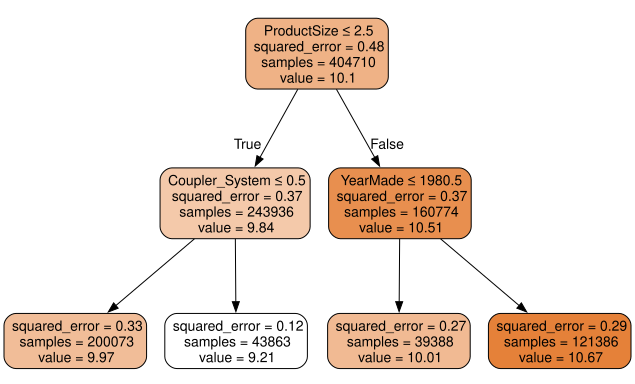

In [60]:
draw_tree(model, Xs, size=10)

the top node represent the initial model, no splits, all data is in one group as the size is 395371 which is the whoe dataset, it does nothing, and will always predict the value to be the average of the whole dataset with mean squared error of 0.48, moving down to the left is all the record with `ProductSize` smaller than 2.5, in the right is the record with `ProductSize` greater or equal to 2.5, and so on

You can notice here that our decision tree algorithm did find single binary split that separated high value from lower value of auction price, the node in the left have lower `SalePrice` than the one in the right

Here's another way to represent our tree

/home/monarch/workplace/bb_bulldozer/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


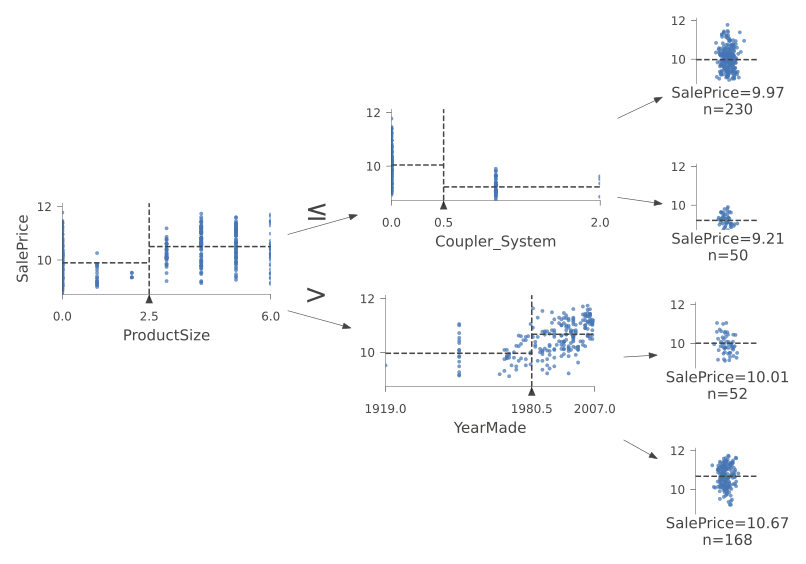

In [61]:
samp_idx = np.random.permutation(len(y))[:500]
viz_model = dtreeviz.model(model, X_train=Xs.iloc[samp_idx], y_train=y.iloc[samp_idx],
                           feature_names=Xs.columns, target_name=dep_var, )
viz_model.view(scale=2, fontname='DejaVu Sans', label_fontsize=10, orientation='LR')

This shows a chart of the distribution of the data for each split point.

In [62]:
def m_rmse(m, xs, y): return rmse(m.predict(xs), y)

In [63]:
model = DecisionTreeRegressor(min_samples_leaf=25)
model.fit(Xs, y)
m_rmse(model, Xs, y), m_rmse(model, val_Xs, val_y)

(0.21085574376445976, 0.2640404545572763)

In [64]:
model.get_n_leaves()

np.int64(12434)

## Random forest

In [65]:
model = RandomForestRegressor(n_estimators=30, max_samples=200_000, max_features=0.5, 
                              min_samples_leaf=10, oob_score=True, n_jobs=-1).fit(Xs, y)

In [66]:
m_rmse(model, Xs,y), m_rmse(model, val_Xs, val_y)

(0.19371716236658454, 0.23700212776117274)

In [67]:
preds = np.stack([t.predict(val_Xs.values) for t in model.estimators_])
preds

array([[10.24761306, 10.08529323,  9.35230912, ...,  9.40835337,
         9.08292526,  9.08292526],
       [10.06517876,  9.86676829,  9.17042189, ...,  9.56678579,
         9.25984141,  9.25984141],
       [10.27585031, 10.25256178,  9.25187507, ...,  9.42577585,
         9.28158091,  9.28158091],
       ...,
       [ 9.85581661, 10.01275403,  9.29032373, ...,  9.3842959 ,
         9.19863588,  9.19863588],
       [10.10568691,  9.92864462,  9.38640856, ...,  9.36669982,
         9.22563323,  9.22563323],
       [10.05930102, 10.12270938,  9.20824065, ...,  9.60219786,
         9.20180512,  9.20180512]], shape=(30, 7988))

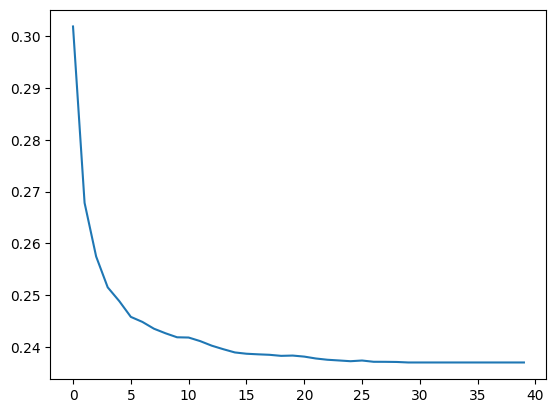

In [68]:
plt.plot([rmse(preds[:i+1].mean(axis=0), val_y) for i in range(40)])